In [6]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['font.size'] = 10
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['legend.frameon'] = False
plt.rcParams['legend.loc'] = 'best'

plt.rcParams['legend.fontsize'] = 10
plt.rcParams['legend.title_fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 8  # Taille des labels des xticks
plt.rcParams['ytick.labelsize'] = 8  # Taille des labels des yticks
plt.rcParams['legend.fontsize'] = 8 # Taille des labels de la légende
plt.rcParams['figure.titlesize'] = 12  # Taille du titre de la figure
plt.rcParams['axes.titlesize'] = 12  # Taille du titre des sous-graphes
plt.rcParams['axes.labelsize'] = 10  # Taille des labels des axes

path="/media/nicolascatz/ssdcalcul/Projets/M1_NEURO_APP_NC"
# path="D:/DATA/Projets/M1_NEURO_APP_NC"

pathresults=path+"/out/"
pathscripts=path+"/scripts/"

file=np.load(pathresults+"FileAll.npz", allow_pickle=True)["arr_0"]
unit=np.load(pathresults+"UnitAll.npz", allow_pickle=True)["arr_0"]
print(unit.shape)
print("nb of units: ", file.shape[0])

nbunits = unit.shape[0]
nbunits

(918,)
nb of units:  918


918

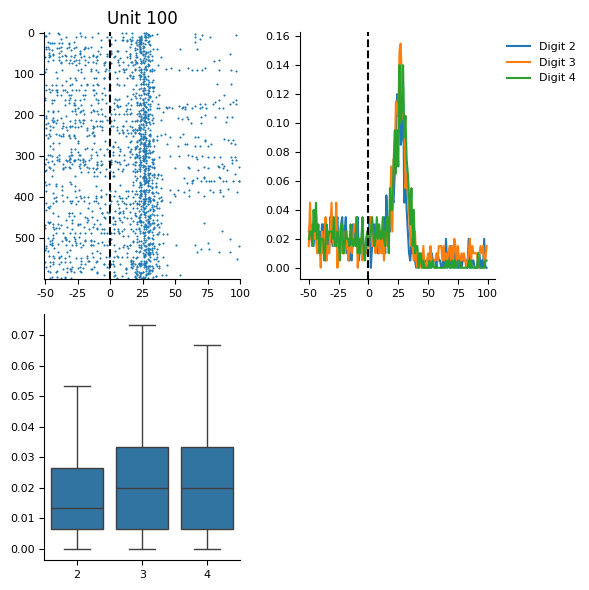

In [ ]:
import scipy.stats as stats
import seaborn as sns


n=100

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(6,6))
ax_flat = ax.flatten()

ax_flat[0].spy(unit[n][:,50:200],aspect='auto',markersize=0.5)
ax_flat[0].xaxis.set_ticks_position('bottom')
ax_flat[0].axvline(x=50, color='k', linestyle='--')
ax_flat[0].set_title("Unit "+str(n))
ax_flat[0].set_xticks([0,25,50,75,100,125,150])
ax_flat[0].set_xticklabels([-50, -25, 0, 25, 50, 75, 100])

ax_flat[1].plot(unit[n][unit[n][:,0]==2][:,50:200].mean(axis=0), label="Digit 2")
ax_flat[1].plot(unit[n][unit[n][:,0]==3][:,50:200].mean(axis=0), label="Digit 3")
ax_flat[1].plot(unit[n][unit[n][:,0]==4][:,50:200].mean(axis=0), label="Digit 4")
ax_flat[1].legend(frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')
ax_flat[1].axvline(x=50, color='k', linestyle='--')

ax_flat[1].set_xticks([0,25,50,75,100,125,150])
ax_flat[1].set_xticklabels([-50, -25, 0, 25, 50, 75, 100])

ax_flat[1].spines['right'].set_visible(False)
ax_flat[1].spines['top'].set_visible(False)

sns.boxplot(x=unit[n][:,0], y=unit[n][:,50:200].mean(axis=1), ax=ax_flat[2],showfliers=False)
ax_flat[2].spines['right'].set_visible(False)
ax_flat[2].spines['top'].set_visible(False)
ax_flat[3].axis('off')
plt.tight_layout()
plt.show()

Prepare data for 2 3 4 decoding

In [8]:
import random
UnitPop=[]
for n in range(nbunits):

    unit2=unit[n][unit[n][:,0]==2][:,50:200]
    unit3=unit[n][unit[n][:,0]==3][:,50:200]
    unit4=unit[n][unit[n][:,0]==4][:,50:200]

    if unit2.shape[0] > 100 and unit3.shape[0] > 100 and unit4.shape[0] > 100:
        unit300=np.concatenate((unit2[random.sample(range(unit2.shape[0]), 100),:],
                            unit3[random.sample(range(unit3.shape[0]), 100),:],
                            unit4[random.sample(range(unit4.shape[0]), 100),:]), axis=0)
        

        UnitTime=np.sum(unit300[:,60:100], axis=1) # sum spikes in the time window

        UnitTime[UnitTime>0]=1 # binarize    


        UnitPop.extend([UnitTime])


StimTarget = [2] * 100
StimTarget.extend([3] * 100)
StimTarget.extend([4] * 100)
print(StimTarget)

UnitPop=np.array(UnitPop)
UnitPop=UnitPop.T
print(UnitPop.shape)

[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
(300, 795)


decoding control data

Mean Accuracy:  0.9994444444444445
Mean Accuracy Shuffled:  0.31555555555555553


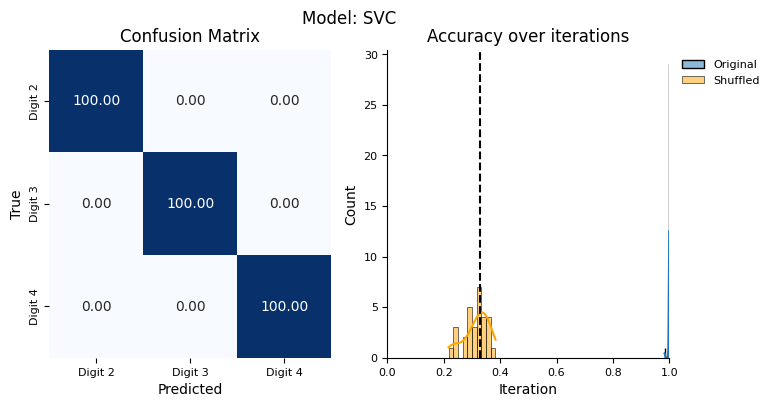

Mean Accuracy:  0.9816666666666666
Mean Accuracy Shuffled:  0.3572222222222223


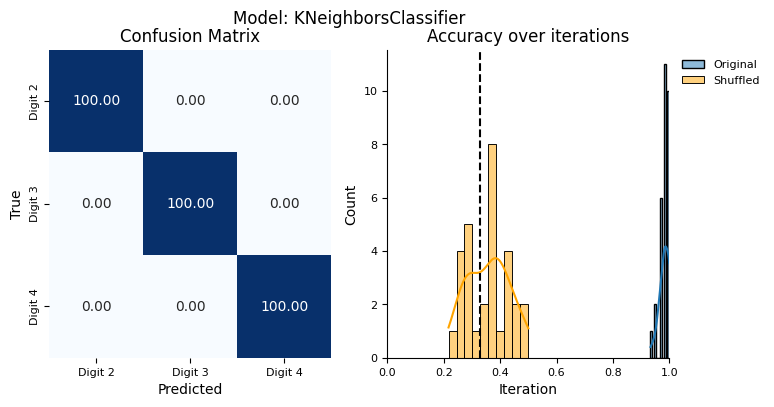

In [9]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC


# model = KNeighborsClassifier(n_neighbors=17)
svc = SVC(kernel='linear', C=1)
knn = KNeighborsClassifier(n_neighbors=17)
list_models = [svc, knn]


for model in list_models:
    X = UnitPop[:,:]
    y = StimTarget

    CM=np.zeros((3,3))
    AccuracyAll=[]
    for i in range(30):
        # Diviser les données en ensembles d'entraînement et de test
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)
        accuracy = []
        # Créer et entraîner le modèle KNN
        model.fit(X_train, y_train)

        # Faire des prédictions sur l'ensemble de test
        y_pred = model.predict(X_test)

        # Évaluer la performance du modèle
        AccuracyAll.append(accuracy_score(y_test, y_pred))

        cm = confusion_matrix(y_test, y_pred)
        CM+=cm

    AccuracyAllShuff=[]
    for i in range(30):
        # Diviser les données en ensembles d'entraînement et de test
        X_train, X_test, y_train, y_test = train_test_split(X, np.random.permutation(y), test_size=0.2, random_state=i)
        accuracy = []
        # Créer et entraîner le modèle KNN
        model.fit(X_train, y_train)

        # Faire des prédictions sur l'ensemble de test
        y_pred = model.predict(X_test)

        # Évaluer la performance du modèle
        AccuracyAllShuff.append(accuracy_score(y_test, y_pred))

    

    print("Mean Accuracy: ", np.mean(AccuracyAll))
    print("Mean Accuracy Shuffled: ", np.mean(AccuracyAllShuff))

    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, ax = plt.subplots(figsize=(8,4),nrows=1,ncols=2)
    sns.heatmap(cm_normalized*100, annot=True, fmt='.2f',cmap='Blues',
                xticklabels=['Digit 2', 'Digit 3', 'Digit 4'],
                yticklabels=['Digit 2', 'Digit 3', 'Digit 4'],
                cbar=False, ax=ax[0])

    ax[0].set_xlabel('Predicted')
    ax[0].set_ylabel('True')
    ax[0].set_title('Confusion Matrix')
    sns.histplot(AccuracyAll, ax=ax[1], bins=10, kde=True, label='Original')
    sns.histplot(AccuracyAllShuff, ax=ax[1], bins=10, kde=True, color='orange', label='Shuffled')
    ax[1].legend(frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')
    ax[1].set_title('Accuracy over iterations')
    ax[1].set_xlabel('Iteration')
    ax[1].set_xlim(0, 1)
    ax[1].axvline(x=0.33, color='k', linestyle='--', label='Chance Level')
    fig.suptitle('Model: '+model.__class__.__name__)    
    plt.show()

Validation curve du KNN

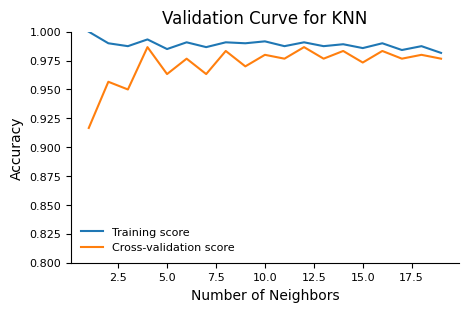

In [10]:
from sklearn.model_selection import validation_curve

# Définir le modèle et le paramètre à valider
model = KNeighborsClassifier()
param_name = 'n_neighbors'
param_range = np.arange(1, 20)

# Calculer la courbe de validation
train_scores, test_scores = validation_curve(
    model, X, y, param_name=param_name, param_range=param_range, cv=5, scoring='accuracy'
)

# Tracer la courbe de validation
plt.figure(figsize=(5, 3))
plt.plot(param_range, np.mean(train_scores, axis=1), label='Training score')
plt.plot(param_range, np.mean(test_scores, axis=1), label='Cross-validation score')
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.title('Validation Curve for KNN')
plt.ylim(0.8, 1.0)
plt.legend()
plt.show()

Perceptron for 2 classes

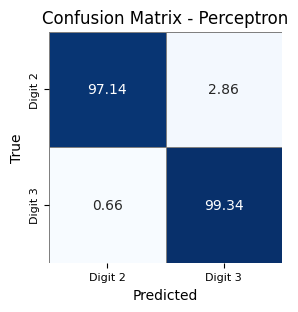

In [14]:
## MLP for N neurons and 2 classes
### using sklearn Perceptron

from sklearn.linear_model import Perceptron

X=UnitPop[0:200,:] # use all neurons as features

y=StimTarget[0:200] # to have labels 0,1,2,3 instead of 2,3,4,5

CM=np.zeros((2,2))
for i in range(30):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)

    # Create and train the Perceptron model
    perceptron = Perceptron(random_state=15, max_iter=9000) # increase max_iter if not converged
    perceptron.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = perceptron.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    # print(f"Accuracy: {accuracy:.2f}")

    cm = confusion_matrix(y_test, y_pred)
    CM+=cm

cm_normalized = CM.astype('float') / CM.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(3,3))
sns.heatmap(cm_normalized*100, annot=True, fmt='.2f', cmap='Blues', cbar=False, ax=ax,linewidths=0.5, linecolor='gray',xticklabels=['Digit 2', 'Digit 3'], yticklabels=['Digit 2', 'Digit 3'])
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.title('Confusion Matrix - Perceptron')
plt.show()




MLP 3 classes

In [18]:
## MLP for N neurons and 4 classes
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X=UnitPop[:,:]
y=StimTarget
AccScore_MLP=[]
layer_sizes = [32]

for l1 in layer_sizes:
    CM_NN=np.zeros((3,3))
    split=0
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8,test_size=0.2, random_state=split)

    model = Sequential()
    # model.add(Dense(X_train.shape[1], activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dense(l1, activation='relu'))
    model.add(Dense(3, activation='softmax'))

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    # Keras expects array-like labels and class indices starting at 0 for sparse_categorical_crossentropy
    X_train = np.asarray(X_train, dtype=np.float32)
    X_test = np.asarray(X_test, dtype=np.float32)
    y_train = np.asarray(y_train, dtype=np.int32) - 2   # 2,3,4 -> 0,1,2
    y_test = np.asarray(y_test, dtype=np.int32) - 2

    model.fit(X_train, y_train, epochs=50, verbose=0)

    history = model.history.history
    y_pred = model.predict(X_test)
    y_pred = np.argmax(y_pred, axis=1)
    AccScore_MLP.append(accuracy_score(y_test, y_pred))

    loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
    accuracy = accuracy * 100


/media/nicolascatz/ssdcalcul/Projets/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1778508706.930903  135291 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_14050__.13
I0000 00:00:1778508707.981556  135294 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_14050__.13


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 395ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 496ms/step - accuracy: 1.0000 - loss: 0.0047


In [63]:
## MLP for N neurons and 4 classes
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


## UNIT POP 

import random
UnitPop=[]
unit300pop=[]
for n in range(nbunits):

    unit2=unit[n][unit[n][:,0]==2][:,50:200]
    unit3=unit[n][unit[n][:,0]==3][:,50:200]
    unit4=unit[n][unit[n][:,0]==4][:,50:200]

    if unit2.shape[0] > 100 and unit3.shape[0] > 100 and unit4.shape[0] > 100:
        unit300=np.concatenate((unit2[random.sample(range(unit2.shape[0]), 100),:],
                            unit3[random.sample(range(unit3.shape[0]), 100),:],
                            unit4[random.sample(range(unit4.shape[0]), 100),:]), axis=0)
        

        unit300pop.append(unit300)


L=np.shape(unit300pop)
L

(795, 300, 150)

In [68]:
onsettime=0
binwin=2
accuracytime=[]
for offsettime in range(0, 100, binwin):

    UnitPop=[]

    for n in range(L[0]):
        UnitTime=np.sum(unit300pop[n][:,onsettime:offsettime], axis=1) # sum spikes in the time window
        UnitTime[UnitTime>0]=1 # binarize    
        UnitPop.extend([UnitTime])



    StimTarget = [2] * 100
    StimTarget.extend([3] * 100)
    StimTarget.extend([4] * 100)
    # print(StimTarget)

    UnitPop=np.array(UnitPop)
    UnitPop=UnitPop.T
    # print(UnitPop.shape)


    X=UnitPop[:,:]
    y=StimTarget
    AccScore_MLP=[]

    layer_sizes = 32

    CM_NN=np.zeros((3,3))
    split=0
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8,test_size=0.2, random_state=split)

    model = Sequential()
    # model.add(Dense(X_train.shape[1], activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dense(layer_sizes, activation='relu'))
    model.add(Dense(3, activation='softmax'))

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    # Keras expects array-like labels and class indices starting at 0 for sparse_categorical_crossentropy
    X_train = np.asarray(X_train, dtype=np.float32)
    X_test = np.asarray(X_test, dtype=np.float32)
    y_train = np.asarray(y_train, dtype=np.int32) - 2   # 2,3,4 -> 0,1,2
    y_test = np.asarray(y_test, dtype=np.int32) - 2

    model.fit(X_train, y_train, epochs=50, verbose=0)

    history = model.history.history
    y_pred = model.predict(X_test)
    y_pred = np.argmax(y_pred, axis=1)
    AccScore_MLP.append(accuracy_score(y_test, y_pred))

    loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
    accuracytime.append(accuracy * 100)

        ####


/media/nicolascatz/ssdcalcul/Projets/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1778509907.466141  135295 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_67978__.13
I0000 00:00:1778509908.410514  135295 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_67978__.13


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 400ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 506ms/step - accuracy: 0.3333 - loss: 1.0986


/media/nicolascatz/ssdcalcul/Projets/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1778509914.436570  135292 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_71830__.13
I0000 00:00:1778509915.375388  135292 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_71830__.13


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 396ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step - accuracy: 0.3833 - loss: 2.1854


/media/nicolascatz/ssdcalcul/Projets/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1778509921.353906  135292 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_75682__.13
I0000 00:00:1778509922.303947  135292 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_75682__.13


...

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 412ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step - accuracy: 0.9833 - loss: 0.0180


/media/nicolascatz/ssdcalcul/Projets/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1778510243.395432  135291 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_252874__.13
I0000 00:00:1778510244.350378  135293 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_252874__.13


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 395ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step - accuracy: 1.0000 - loss: 0.0147


/media/nicolascatz/ssdcalcul/Projets/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1778510250.345208  135293 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_256726__.13
I0000 00:00:1778510251.300424  135293 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_256726__.13


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 397ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 499ms/step - accuracy: 1.0000 - loss: 0.0142


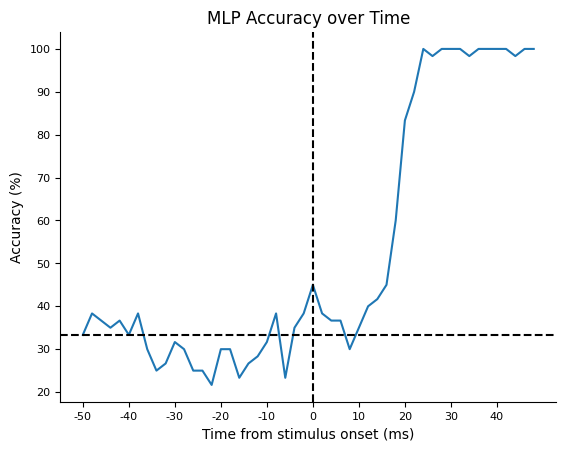

In [81]:
plt.plot(range(0, 100, binwin), accuracytime)
plt.xlabel("Time from stimulus onset (ms)")
plt.ylabel("Accuracy (%)")
plt.title("MLP Accuracy over Time")
plt.axhline(y=33.33, color='k', linestyle='--', label='Chance Level')
plt.axvline(x=50, color='k', linestyle='--', label='Stimulus Onset')
plt.xticks(range(0, 100, 10), labels=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40])
plt.show()

In [59]:

X=UnitPop[:,:]
y=StimTarget
AccScore_MLP=[]

layer_sizes = 32

CM_NN=np.zeros((3,3))
split=0
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8,test_size=0.2, random_state=split)

model = Sequential()
# model.add(Dense(X_train.shape[1], activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(layer_sizes, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Keras expects array-like labels and class indices starting at 0 for sparse_categorical_crossentropy
X_train = np.asarray(X_train, dtype=np.float32)
X_test = np.asarray(X_test, dtype=np.float32)
y_train = np.asarray(y_train, dtype=np.int32) - 2   # 2,3,4 -> 0,1,2
y_test = np.asarray(y_test, dtype=np.int32) - 2

model.fit(X_train, y_train, epochs=50, verbose=0)

history = model.history.history
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
AccScore_MLP.append(accuracy_score(y_test, y_pred))

loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
accuracy = accuracy * 100


/media/nicolascatz/ssdcalcul/Projets/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1778509559.340470  135294 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_21754__.13
I0000 00:00:1778509560.375430  135295 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_21754__.13


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 425ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 516ms/step - accuracy: 1.0000 - loss: 0.0063


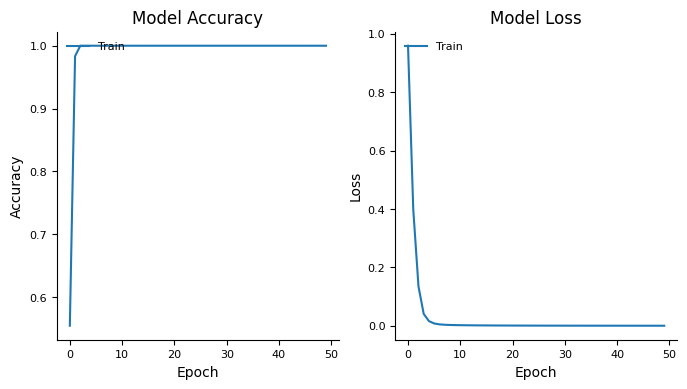

Test accuracy: 100.00%
loss: 0.0063


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 128)            │       101,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 318,347 (1.21 MB)

 Trainable params: 106,115 (414.51 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 212,232 (829.04 KB)

In [60]:

fig,ax=plt.subplots(nrows=1,ncols=2, figsize=(8,4))

ax[0].plot(history['accuracy'])
ax[0].set_title('Model Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(['Train'], loc='upper left')

ax[1].plot(history['loss'])
ax[1].set_title('Model Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(['Train'], loc='upper left')



plt.show()

print(f'Test accuracy: {accuracy:.2f}%')
print(f'loss: {loss:.4f}')

cm=confusion_matrix(y_test, y_pred)
CM_NN += cm

model.summary()